In [14]:
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [15]:
# ── Load ─────────────────────────────────────────────────────────────
data = load_breast_cancer()
X, y = data.data, data.target

print("Feature matrix shape:", X.shape)     # (569, 30)
print("Target shape:", y.shape)              # (569,)
print("Feature names (first 5):", data.feature_names[:5])
print("Class distribution:", np.bincount(y))  # [212, 357] — 0=malignant, 1=benign

# ── Split ────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Scale ────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Feature matrix shape: (569, 30)
Target shape: (569,)
Feature names (first 5): ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']
Class distribution: [212 357]


In [16]:
class BreastCancerDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)  # shape (n,1) to match model output

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = BreastCancerDataset(X_train, y_train)
test_dataset = BreastCancerDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [17]:
# ── Classifier ────────────────────────────────────────────────────────────
class BreastCancerNet(nn.Module):
    def __init__(self, input_dim=30):
        super().__init__()
        # Make new layers and also define activation functions.
        self.layer1 = nn.Linear(input_dim, 10)
        self.layer2 = nn.Linear(10, 5)
        self.layer3 = nn.Linear(5, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Forward Traverse using different layers .
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.sigmoid(self.layer3(x))
        return x

# Pass the model with X_train #columns
model = BreastCancerNet(input_dim=X_train.shape[1])
print(model)

BreastCancerNet(
  (layer1): Linear(in_features=30, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=5, bias=True)
  (layer3): Linear(in_features=5, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)


In [18]:
# Pass on the batch size 
sample_X, sample_y = next(iter(train_loader))
print("Batch X shape:", sample_X.shape)   # expect (32, 30)
print("Batch y shape:", sample_y.shape)   # expect (32, 1)

output = model(sample_X)
print("Model output shape:", output.shape)  # expect (32, 1)

Batch X shape: torch.Size([32, 30])
Batch y shape: torch.Size([32, 1])
Model output shape: torch.Size([32, 1])


In [19]:
import matplotlib.pyplot as plt

def train_model(model, train_loader, test_loader, criterion, optimizer, n_epochs=50):
    history = {
        "train_loss": [],
        "test_loss": [],
        "test_accuracy": []
    }

    for epoch in range(n_epochs):
        # ── Training phase ──────────────────────────────────────────
        model.train()
        running_train_loss = 0.0

        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            y_pred = model(batch_X)
            loss = criterion(y_pred, batch_y)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item()

        avg_train_loss = running_train_loss / len(train_loader)

        # ── Evaluation phase ─────────────────────────────────────────
        model.eval()
        running_test_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                y_pred = model(batch_X)
                loss = criterion(y_pred, batch_y)
                running_test_loss += loss.item()

                predicted_labels = (y_pred >= 0.5).float()
                correct += (predicted_labels == batch_y).sum().item()
                total += batch_y.size(0)

        avg_test_loss = running_test_loss / len(test_loader)
        test_accuracy = correct / total

        history["train_loss"].append(avg_train_loss)
        history["test_loss"].append(avg_test_loss)
        history["test_accuracy"].append(test_accuracy)

        if epoch % 5 == 0:
            print(f"Epoch {epoch}: Train Loss = {avg_train_loss:.4f}, "
                  f"Test Loss = {avg_test_loss:.4f}, Test Accuracy = {test_accuracy:.4f}")

    return history

In [20]:
# Make a custom plotting function
def plot_history(history):
    epochs = range(len(history["train_loss"]))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Loss subplot
    axes[0].plot(epochs, history["train_loss"], label="Train Loss", color="#2a78d6")
    axes[0].plot(epochs, history["test_loss"], label="Test Loss", color="#e34948")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Train vs Test Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Accuracy subplot
    axes[1].plot(epochs, history["test_accuracy"], label="Test Accuracy", color="#1baf7a")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title("Test Accuracy over Training")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

Epoch 0: Train Loss = 0.7229, Test Loss = 0.7142, Test Accuracy = 0.3684
Epoch 5: Train Loss = 0.5828, Test Loss = 0.5618, Test Accuracy = 0.8860
Epoch 10: Train Loss = 0.2878, Test Loss = 0.2954, Test Accuracy = 0.9211
Epoch 15: Train Loss = 0.1540, Test Loss = 0.1797, Test Accuracy = 0.9386
Epoch 20: Train Loss = 0.1156, Test Loss = 0.1365, Test Accuracy = 0.9561
Epoch 25: Train Loss = 0.0900, Test Loss = 0.1155, Test Accuracy = 0.9561
Epoch 30: Train Loss = 0.0748, Test Loss = 0.1041, Test Accuracy = 0.9474
Epoch 35: Train Loss = 0.0638, Test Loss = 0.0941, Test Accuracy = 0.9649
Epoch 40: Train Loss = 0.0550, Test Loss = 0.0889, Test Accuracy = 0.9649
Epoch 45: Train Loss = 0.0507, Test Loss = 0.0881, Test Accuracy = 0.9561


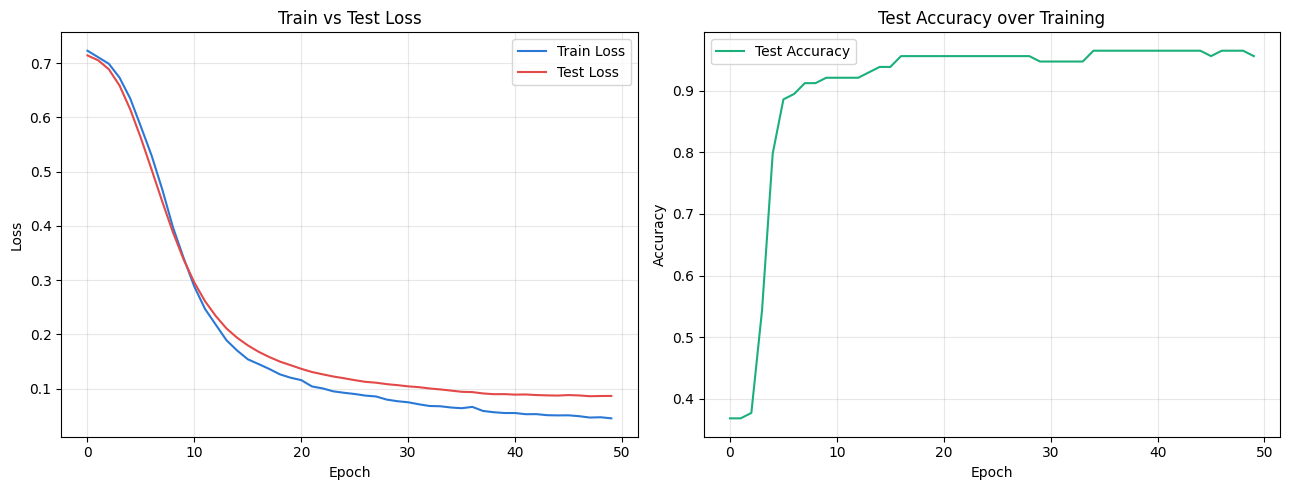

In [21]:
model = BreastCancerNet(input_dim=X_train.shape[1])
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

history = train_model(model, train_loader, test_loader, criterion, optimizer, n_epochs=50)
plot_history(history)